# Project 1: Retail Store Sales & Customer Analysis

## Project Objective

This project analyses retail transaction data to evaluate sales performance, customer purchasing behaviour, product category performance, and monthly sales trends.

The objective is to generate business insights using exploratory data analysis (EDA) and data visualisation to support data-driven decision-making.

---

## Dataset

The dataset contains 1,000 retail transactions recorded during 2023.

Each transaction includes customer demographics, product information, purchase quantity, price per unit, and total transaction value.

---

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

## 1. Import Libraries

The analysis will use Python libraries for data manipulation and visualization.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots appear in the notebook
%matplotlib inline

# Optional: slightly larger default figure size
plt.rcParams["figure.figsize"] = (10, 6)

## 2. Load Dataset

### Business Question

What information is available in the retail transaction dataset?

In [4]:
# Load the dataset
df = pd.read_csv("../data/retail_sales_dataset.csv")

# Display the first 5 rows
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


### Initial Observation

The dataset contains transaction-level retail information including customer demographics, product categories, quantity purchased, price per unit, and total transaction amount.

## 3. Data Overview

### Business Question

How large is the dataset and how many variables are available for analysis?

In [45]:
# Number of rows and columns
df.shape

(1000, 11)

### Interpretation

The dataset contains 1,000 transactions and 9 variables.

Each row represents one customer transaction, while each column provides information about customer characteristics, purchased products, and sales details.

### Business Insight

The dataset provides enough transaction records to explore customer behaviour, product category performance, and sales trends.

## 4. Data Understanding

### Business Question

What is the structure and quality of the retail dataset?

We will inspect:
- Column names
- Data types
- Missing values
- Number of non-null records

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


### Interpretation

The dataset contains 1,000 transactions and 9 columns.

The dataset includes:
- Numerical variables such as age, quantity, price per unit, and total amount.
- Categorical variables such as gender and product category.
- Date information stored as text, which will need to be converted into a date format for time-based analysis.

No missing values were identified, so the dataset does not require missing value treatment.

## 5. Data Cleaning

### Business Question

Is the dataset clean and ready for analysis?

In [9]:
# Checking for duplicates
df.duplicated().sum()

np.int64(0)

### Duplicate Check

The dataset contains no duplicate transactions.

This means each row represents a unique customer transaction, and no duplicate records need to be removed.

### Date Format Check

The Date column is currently stored as text. To perform time-based analysis, it needs to be converted into a datetime format.

In [10]:
# Convert 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

In [11]:
# Checking the results of the conversion
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[us]
 2   Customer ID       1000 non-null   str           
 3   Gender            1000 non-null   str           
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   str           
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[us](1), int64(5), str(3)
memory usage: 70.4 KB


### Date Conversion

The Date column was originally stored as text (`object`). It has been successfully converted into a datetime format, allowing time-based analysis such as monthly sales trends and seasonal patterns.

## 6. Exploratory Data Analysis (EDA)

### 6.1 Sales Overview

### Business Question

What is the overall sales performance of the retail store?

In [12]:
# Summary statistics for numerical columns
df.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


### Interpretation

The descriptive statistics provide an overview of the numerical variables in the dataset.

The analysis shows:
- The dataset contains 1,000 transactions.
- Age, quantity, price per unit, and total amount have been summarized using statistical measures.
- The mean values represent the average customer and transaction characteristics.
- The minimum and maximum values help identify the range of values in each variable.
- The standard deviation indicates how much transaction values vary from the average.

### Business Insight

The summary statistics provide an initial understanding of customer purchasing behaviour and transaction patterns. Further analysis will explore which customer groups and product categories contribute most to sales.

### Interpretation

The descriptive statistics provide an overview of customer demographics and transaction behaviour.

The dataset contains 1,000 transactions. Customers have an average age of approximately 41 years, with ages ranging from 18 to 64 years.

Customers purchase an average of approximately 2.5 items per transaction. Product prices vary significantly, with the median price being lower than the average price, suggesting the presence of higher-priced products.

The Total Amount column shows a large difference between the mean ($456) and median ($135), indicating that while many transactions are smaller, some high-value purchases contribute significantly to revenue.

### Business Insight

The retail store serves a diverse customer base and experiences a wide range of purchasing behaviours. Further analysis should investigate which product categories and customer segments contribute most to revenue.

# KPI1: Total Revenue

### Total Revenue

### Business Question

What is the total revenue generated from all transactions?

In [13]:
total_revenue = df["Total Amount"].sum()

total_revenue

np.int64(456000)

### Interpretation

The retail store generated a total revenue of $456,000 across 1,000 transactions during the analysed period.

### Business Insight

The total revenue provides a baseline measure of overall business performance. Further analysis will explore which customer groups, product categories, and time periods contribute most to this revenue.

# KPI2: Number of Transactions

### Number of Transactions

### Business Question

How many customer transactions occurred?

In [14]:
number_of_transactions = df["Transaction ID"].count()

number_of_transactions

np.int64(1000)

### Interpretation

The dataset contains 1,000 customer transactions.

Each transaction represents a single purchase made by a customer, allowing us to analyse overall sales performance and purchasing behaviour.

### Business Insight

The store has 1,000 recorded transactions available for analysis. This provides enough data to identify patterns in customer behaviour, product category performance, and sales trends.

# KPI 3: Average Transaction Value

### Average Transaction Value

### Business Question

What is the average amount spent per transaction?

In [16]:
average_transaction_value = df["Total Amount"].mean()

average_transaction_value

np.float64(456.0)

### Interpretation

The average transaction value is $456, meaning that customers spend approximately $456 per transaction on average.

### Business Insight

The average transaction value provides an understanding of typical customer spending behaviour. Comparing this metric across customer groups, product categories, and time periods can help identify opportunities to increase revenue.

### Sales Performance Summary

In [17]:
sales_summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Number of Transactions",
        "Average Transaction Value"
    ],
    "Value": [
        total_revenue,
        number_of_transactions,
        average_transaction_value
    ]
})

sales_summary

,Metric,Value
0,Total Revenue,456000.0
1,Number of Transactions,1000.0
2,Average Transaction Value,456.0


## 6.2 Product Category Analysis

### Business Question

Which product categories generate the highest revenue?

In [18]:
# Group the data
category_sales = df.groupby("Product Category")["Total Amount"].sum()

category_sales

Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64

### Interpretation

The revenue analysis shows that Electronics generated the highest total revenue at $156,905, followed closely by Clothing at $155,580.

Beauty generated the lowest revenue at $143,515; however, the difference between categories is relatively small, indicating that all three categories contribute significantly to overall sales.

### Business Insight

Electronics and Clothing are the strongest revenue-generating categories. The company should continue supporting these categories while investigating opportunities to increase Beauty category sales through promotions or targeted marketing.

In [19]:
# Converting category_sales which is a pandas Series into a DataFrame for professional presentation and further analysis. This will allow us to reset the index and have a clean DataFrame with 'Product Category' as a column.
category_sales_df = category_sales.reset_index()

category_sales_df

,Product Category,Total Amount
0,Beauty,143515
1,Clothing,155580
2,Electronics,156905


### Revenue by Product Category

A bar chart is used to compare total revenue generated by each product category.

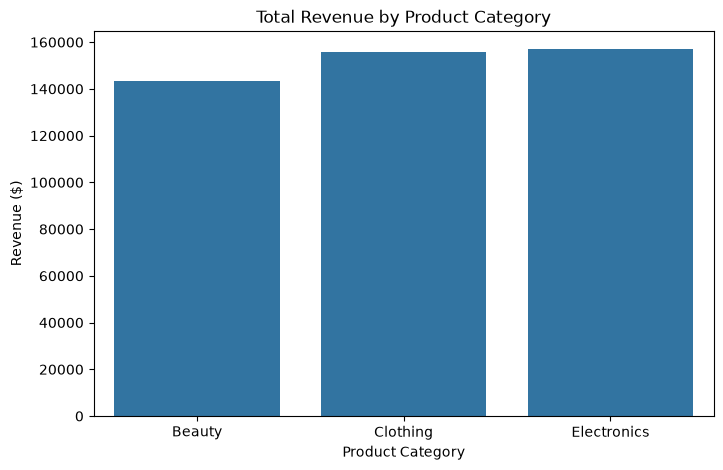

In [21]:
# Creating a revenue comparison chart

plt.figure(figsize=(8,5))

sns.barplot(
    data=category_sales_df,
    x="Product Category",
    y="Total Amount"
)

plt.title("Total Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue ($)")

plt.savefig("../images/revenue_by_category.png", bbox_inches="tight")

plt.show()

## 6.3 Customer Analysis

### Gender Distribution

### Business Question

What is the distribution of customers by gender?

In [22]:
# Count customers by gender
gender_counts = df["Gender"].value_counts()

gender_counts

Gender
Female    510
Male      490
Name: count, dtype: int64

### Interpretation

The dataset contains a relatively balanced distribution of customers by gender.

Female customers account for 510 transactions, while male customers account for 490 transactions.

### Business Insight

The retail store has a balanced customer base across genders. Marketing strategies should consider both customer groups rather than focusing heavily on one gender.

### Customer Distribution by Gender

A bar chart is used to compare the number of transactions by gender.

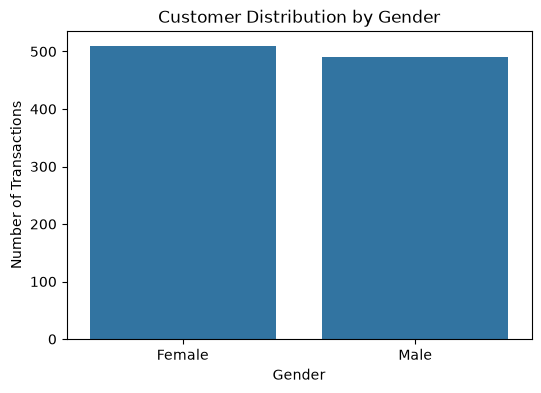

In [23]:
plt.figure(figsize=(6,4))

sns.barplot(
    x=gender_counts.index,
    y=gender_counts.values
)

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Transactions")

plt.savefig("../images/customer_gender_distribution.png", bbox_inches="tight")

plt.show()

### Age Distribution

### Business Question

What is the age distribution of customers?

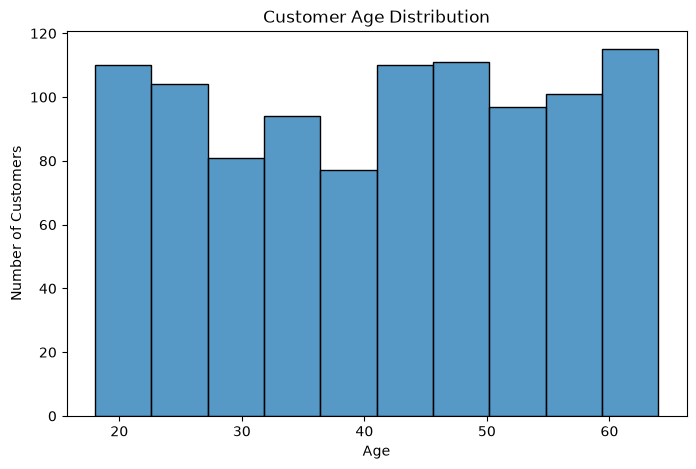

In [25]:
# Histogram to show how many customers fall into different age ranges

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Age",
    bins=10
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.savefig("../images/customer_age_distribution.png", bbox_inches="tight")

plt.show()

### Interpretation

The customer age distribution shows variation across different age groups.

Customer ages range from 18 to 64 years, with some age groups containing more customers than others. The distribution is not completely uniform, indicating differences in customer representation across age ranges.

### Business Insight

The store attracts customers from a wide range of ages. Understanding which age groups are most represented can help the business design more targeted marketing strategies and product recommendations.

### Revenue by Age Group

### Business Question

Which customer age groups contribute the most revenue?

In [26]:
age_bins = [17, 25, 35, 45, 55, 100]

age_labels = [
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56+"
]

df["Age Group"] = pd.cut(
    df["Age"],
    bins=age_bins,
    labels=age_labels
)

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Age Group
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,26-35
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,26-35
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,46-55
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,36-45
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,26-35


In [27]:
# Calculating revenue by age group
age_group_revenue = df.groupby("Age Group", observed=False)["Total Amount"].sum()

age_group_revenue

Age Group
18-25     84550
26-35     98480
36-45     91870
46-55    100690
56+       80410
Name: Total Amount, dtype: int64

### Interpretation

The revenue analysis by age group shows that customers aged 46-55 generated the highest revenue, contributing $100,690 in sales.

The 26-35 age group followed closely with $98,480, while customers aged 56+ generated the lowest revenue at $80,410.

Overall, revenue contribution is relatively balanced across age groups, suggesting that the store attracts valuable customers across different age segments.

### Business Insight

The store should continue targeting multiple age groups rather than focusing on a single demographic. The 46-55 and 26-35 age groups may provide opportunities for targeted marketing campaigns due to their higher contribution to revenue.

In [28]:
# Now create the visualization

# First convert it to a DataFrame

age_group_revenue_df = age_group_revenue.reset_index()

age_group_revenue_df

,Age Group,Total Amount
0,18-25,84550
1,26-35,98480
2,36-45,91870
3,46-55,100690
4,56+,80410


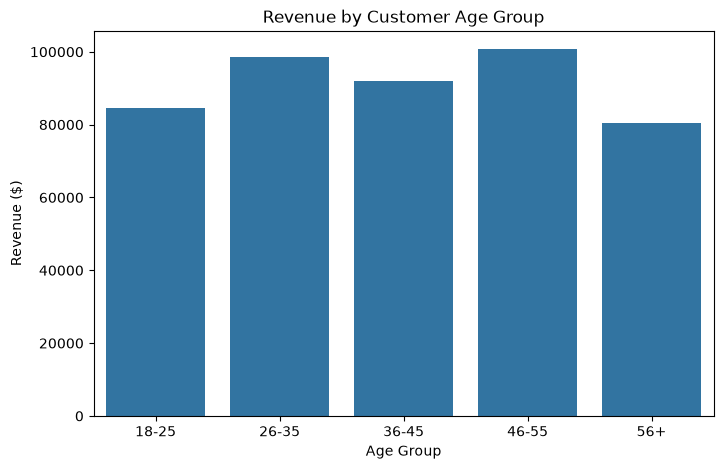

In [30]:
# Creating chart for revenue by age group
plt.figure(figsize=(8,5))

sns.barplot(
    data=age_group_revenue_df,
    x="Age Group",
    y="Total Amount"
)

plt.title("Revenue by Customer Age Group")
plt.xlabel("Age Group")
plt.ylabel("Revenue ($)")

plt.savefig("../images/revenue_by_age_group.png", bbox_inches="tight")

plt.show()

### Key Finding

Customers aged 46-55 generated the highest revenue, contributing $100,690 in sales. The 26-35 age group followed closely with $98,480.

Although the 46-55 group had the highest contribution, revenue was distributed relatively evenly across all age groups. This suggests the retail store has a diverse customer base and should continue engaging multiple age segments.

## 6.4 Time-Based Sales Analysis

### Monthly Sales Trend

### Business Question

How does revenue change across different months?

In [31]:
# Creating a month column
df["Month"] = df["Date"].dt.month_name()

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Age Group,Month
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,26-35,November
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,26-35,February
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,46-55,January
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,36-45,May
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,26-35,May


In [32]:
# Calculate monthly revenue
# Business Question: Which months generated the highest revenue?

monthly_sales = df.groupby("Month")["Total Amount"].sum()

monthly_sales

Month
April        33870
August       36960
December     44690
February     44060
January      36980
July         35465
June         36715
March        28990
May          53150
November     34920
October      46580
September    23620
Name: Total Amount, dtype: int64

### Interpretation

Monthly revenue analysis shows variation in sales performance throughout the year.

May generated the highest revenue with $53,150, while September had the lowest revenue with $23,620.

Sales did not follow a consistent increasing or decreasing trend, suggesting that monthly performance may be influenced by specific business factors such as promotions or customer purchasing patterns.

### Business Insight

The company can investigate the factors behind strong-performing months such as May and October to identify successful strategies. Lower-performing months may present opportunities for targeted campaigns or promotions.

In [33]:
# Now let's create the visualization
# First converting the result into a DataFrame

monthly_sales_df = monthly_sales.reset_index()

monthly_sales_df

,Month,Total Amount
0,April,33870
1,August,36960
2,December,44690
3,February,44060
4,January,36980
5,July,35465
6,June,36715
7,March,28990
8,May,53150
9,November,34920


In [34]:
# Order months correctly
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"
]

monthly_sales_df["Month"] = pd.Categorical(
    monthly_sales_df["Month"],
    categories=month_order,
    ordered=True
)

monthly_sales_df = monthly_sales_df.sort_values("Month")

monthly_sales_df

,Month,Total Amount
4,January,36980
3,February,44060
7,March,28990
0,April,33870
8,May,53150
6,June,36715
5,July,35465
1,August,36960
11,September,23620
10,October,46580


### Monthly Revenue Trend

A line chart is used to show how revenue changes throughout the year.

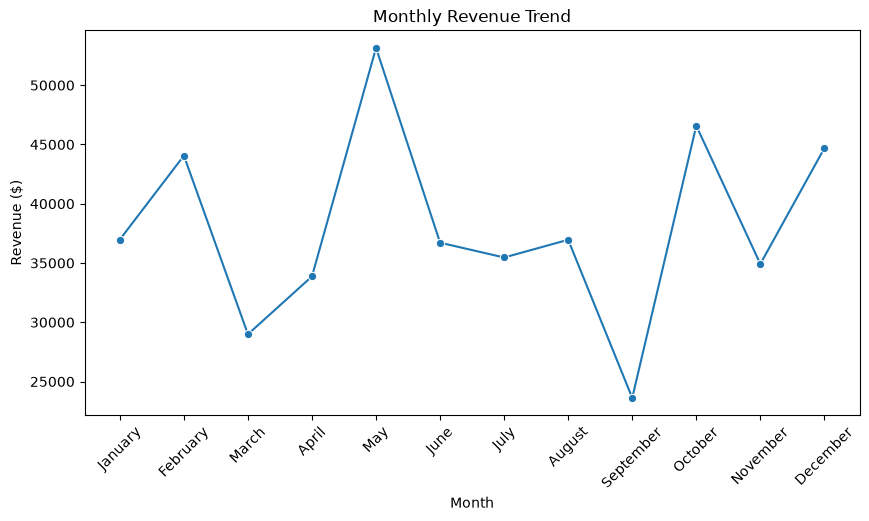

In [36]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=monthly_sales_df,
    x="Month",
    y="Total Amount",
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")

plt.xticks(rotation=45)

plt.savefig("../images/monthly_revenue_trend.png", bbox_inches="tight")

plt.show()

## 6.5 Product Performance Deep Dive

### Quantity Sold by Product Category

### Business Question

Which product categories have the highest sales volume?

In [37]:
category_quantity = df.groupby("Product Category")["Quantity"].sum()

category_quantity

Product Category
Beauty         771
Clothing       894
Electronics    849
Name: Quantity, dtype: int64

### Interpretation

Clothing had the highest sales volume with 894 units sold, followed by Electronics with 849 units and Beauty with 771 units.

The ranking differs from revenue performance, where Electronics generated the highest revenue. This suggests that Electronics products may have a higher average selling price compared with other categories.

### Business Insight

The store should consider both sales volume and revenue when evaluating product performance. Clothing attracts a high number of purchases, while Electronics generates stronger revenue due to higher-value transactions.

In [ ]:
category_quantity_df = category_quantity.reset_index()

category_quantity_df

,Product Category,Quantity
0,Beauty,771
1,Clothing,894
2,Electronics,849


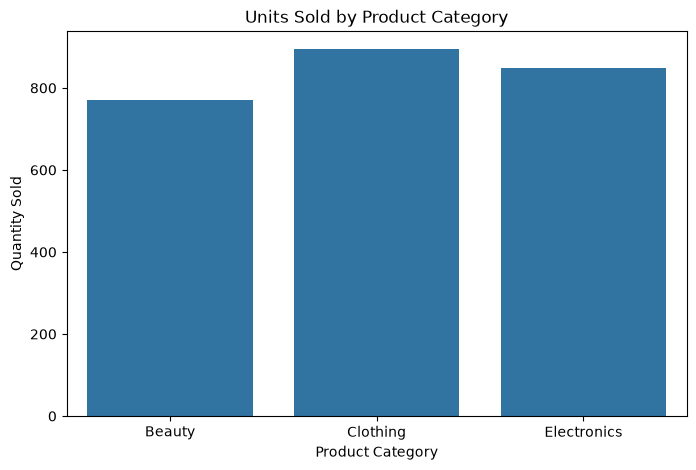

In [40]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=category_quantity_df,
    x="Product Category",
    y="Quantity"
)

plt.title("Units Sold by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Quantity Sold")

plt.savefig("../images/quantity_by_category.png", bbox_inches="tight")

plt.show()

"Clothing has the highest number of units sold, while Electronics generates the highest revenue. This suggests Electronics products may have a higher average selling price."

In [41]:
average_price_category = df.groupby("Product Category")["Price per Unit"].mean()

average_price_category

Product Category
Beauty         184.055375
Clothing       174.287749
Electronics    181.900585
Name: Price per Unit, dtype: float64

### Interpretation

The average price analysis shows that Beauty products have the highest average price per unit at approximately $184, followed closely by Electronics at approximately $182.

Although Electronics does not have the highest sales volume or highest average price, it generated the highest total revenue. This indicates that revenue is influenced by a combination of sales quantity and product pricing.

### Business Insight

The store should monitor both product volume and pricing strategy when evaluating category performance. Electronics and Clothing are strong revenue contributors, while Beauty may have opportunities to increase sales volume.

In [42]:
# Now let's create the visualization.
# First convert to DataFrame
average_price_df = average_price_category.reset_index()

average_price_df

,Product Category,Price per Unit
0,Beauty,184.055375
1,Clothing,174.287749
2,Electronics,181.900585


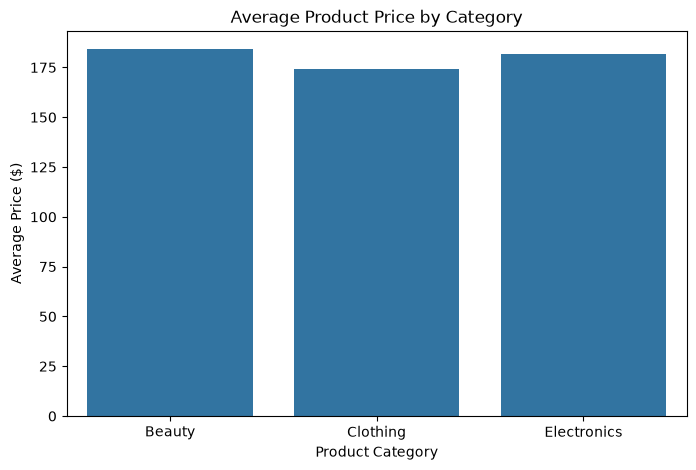

In [44]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=average_price_df,
    x="Product Category",
    y="Price per Unit"
)

plt.title("Average Product Price by Category")
plt.xlabel("Product Category")
plt.ylabel("Average Price ($)")

plt.savefig("../images/average_price_by_category.png", bbox_inches="tight")

plt.show()

# Business Recommendations

Based on the analysis, the following recommendations can be made:

### 1. Focus on High-Revenue Categories

Electronics generated the highest revenue, followed closely by Clothing. The business should continue investing in these categories through inventory management and targeted promotions.

### 2. Increase Beauty Category Sales

Although Beauty products have a similar average price compared with other categories, they generated the lowest revenue. The business could explore promotional campaigns to increase purchase frequency.

### 3. Target Valuable Customer Segments

Customers aged 46-55 generated the highest revenue contribution. Marketing strategies could focus on this segment while continuing to engage customers across all age groups.

### 4. Investigate Monthly Sales Patterns

May was the strongest sales month, while September had the lowest performance. The business could analyse successful activities during high-performing months and introduce campaigns during slower periods.